#  Country Segmentation 


**Objective:**Developed an end-to-end Customer Intelligence System using classification, ensemble learning (Random Forest, XGBoost), and clustering (K-Means, DBSCAN), achieving optimized predictive performance and actionable customer segmentation insights.



## 1. Install & Import Libraries

In [17]:
import io, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

print(" Libraries loaded successfully")

 Libraries loaded successfully


## 2. Load Dataset

In [18]:
import pandas as pd

df = pd.read_csv(
    '/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv'
)

dictionary_df = pd.read_csv(
    '/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv'
)

print("Country Data:", df.shape)
print("Data Dictionary:", dictionary_df.shape)

Country Data: (167, 10)
Data Dictionary: (10, 2)


## 3. Data Inspection

In [19]:
print("─" * 50)
print(f"Shape : {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("─" * 50)
display(df.dtypes.rename('dtype'))
display(df.describe().T.round(2))

──────────────────────────────────────────────────
Shape : (167, 10)
Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
──────────────────────────────────────────────────


country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
Name: dtype, dtype: object

,count,mean,std,min,25%,50%,75%,max
child_mort,167.00,38.27,40.33,2.60,8.25,19.30,62.10,208.00
exports,167.00,41.11,27.41,0.11,23.80,35.00,51.35,200.00
health,167.00,6.82,2.75,1.81,4.92,6.32,8.60,17.90
imports,167.00,46.89,24.21,0.07,30.20,43.30,58.75,174.00
income,167.00,17144.69,19278.07,609.00,3355.00,9960.00,22800.00,125000.00
inflation,167.00,7.78,10.57,-4.21,1.81,5.39,10.75,104.00
life_expec,167.00,70.56,8.89,32.10,65.30,73.10,76.80,82.80
total_fer,167.00,2.95,1.51,1.15,1.80,2.41,3.88,7.49
gdpp,167.00,12964.16,18328.70,231.00,1330.00,4660.00,14050.00,105000.00


In [20]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values per column:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Duplicate rows: 0


## 4. Data Cleaning

In [21]:
df.columns = [c.strip().lower() for c in df.columns]

# Drop duplicates
df = df.drop_duplicates().reset_index(drop=True)

# Ensure numeric columns are correctly typed
numeric_cols = [c for c in df.columns if c != 'country']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill any remaining NaNs with column median (robust to outliers)
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print(" Cleaning complete")
print(f"Final shape : {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()

 Cleaning complete
Final shape : (167, 10)
Missing values: 0


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553
1,Albania,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090
2,Algeria,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460
3,Angola,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530
4,Antigua and Barbuda,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200


## 5. Exploratory Data Analysis (EDA)

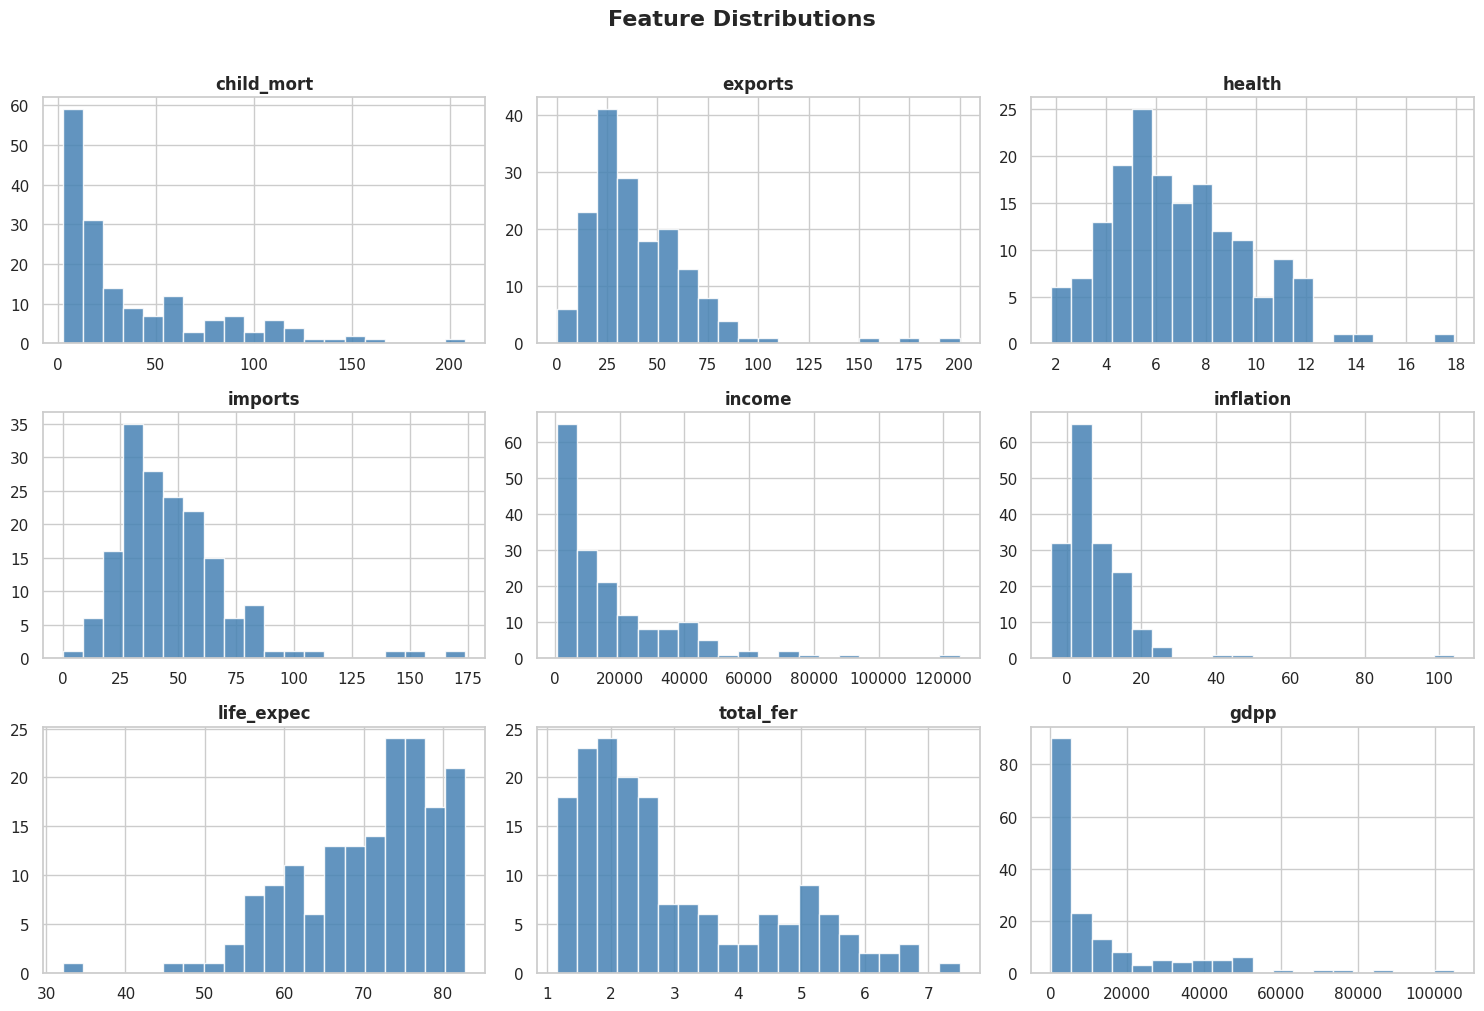

In [22]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

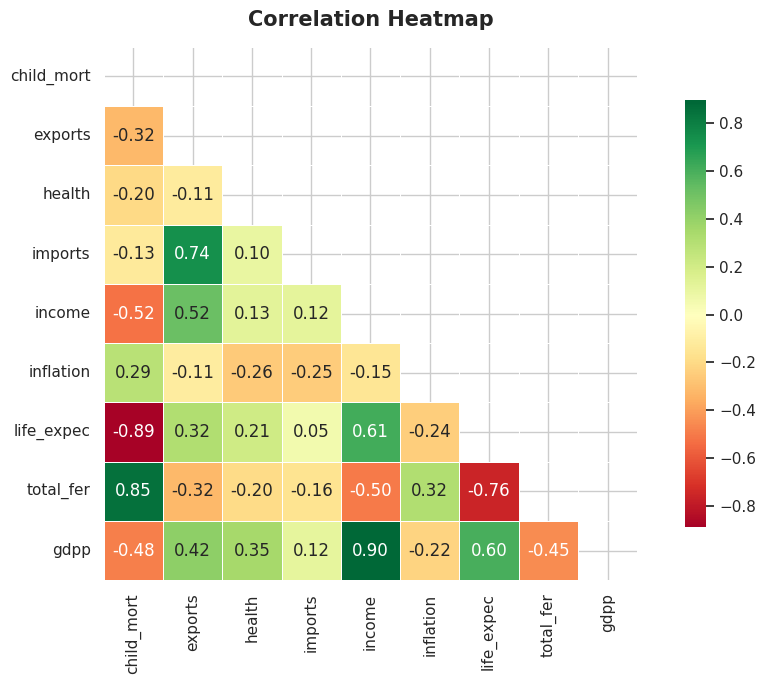

Key correlations:
 • child_mort ↔ life_expec : -0.89
 • income     ↔ gdpp       : 0.9
 • child_mort ↔ total_fer  : 0.85


In [23]:
plt.figure(figsize=(10, 7))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("Key correlations:")
print(" • child_mort ↔ life_expec :", round(corr.loc['child_mort','life_expec'], 2))
print(" • income     ↔ gdpp       :", round(corr.loc['income','gdpp'], 2))
print(" • child_mort ↔ total_fer  :", round(corr.loc['child_mort','total_fer'], 2))

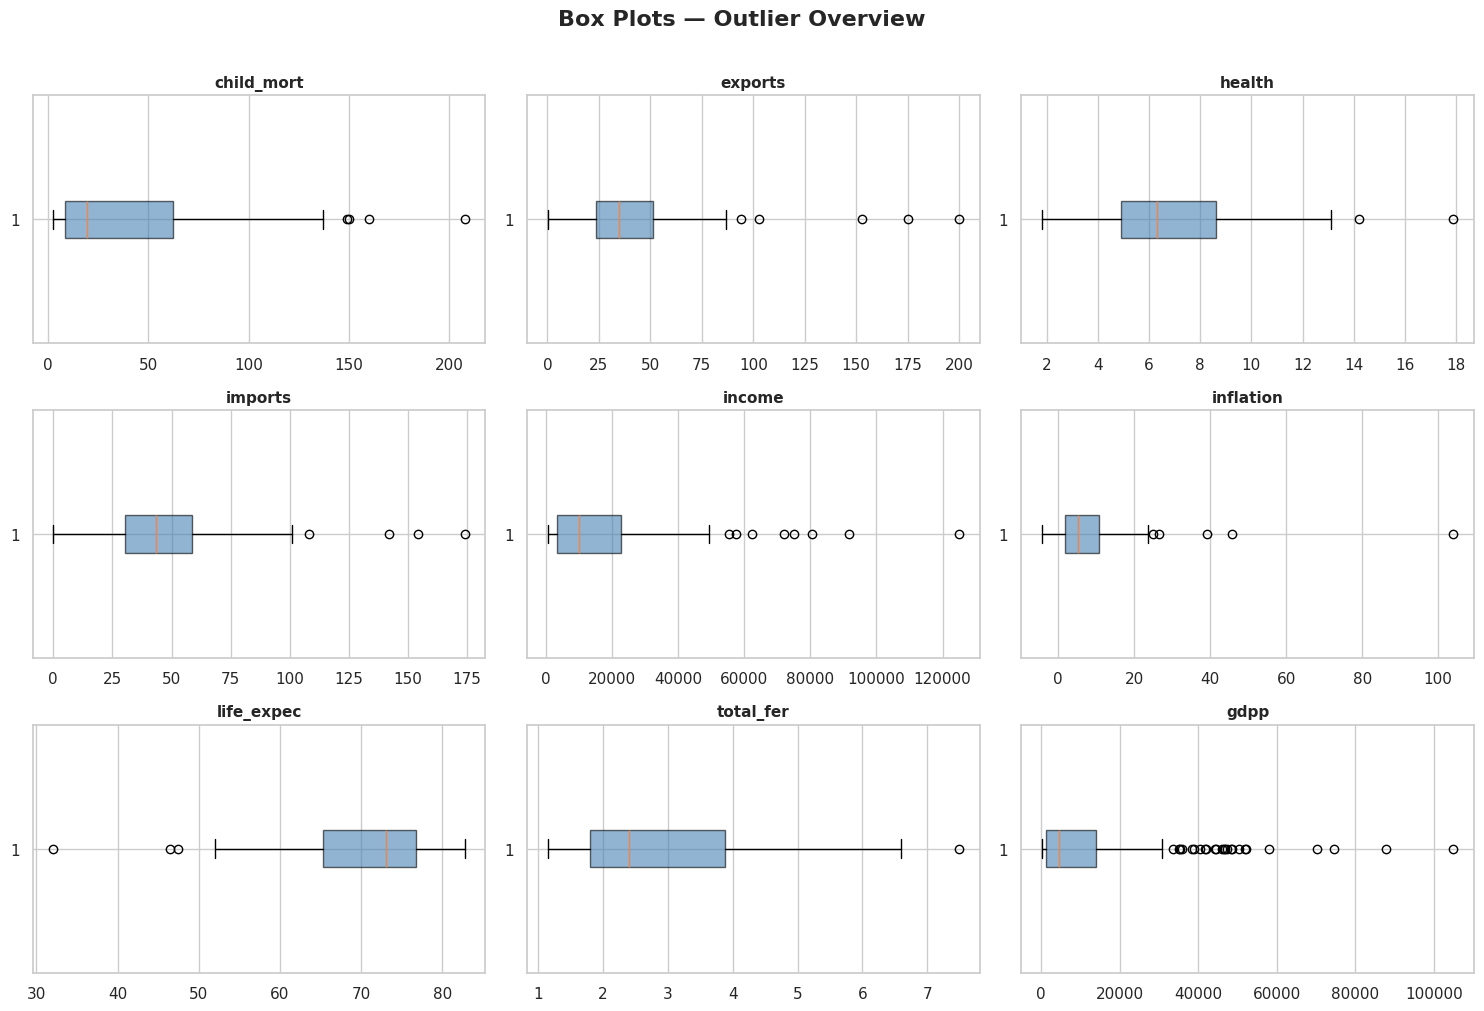

In [24]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), vert=False, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=11, fontweight='bold')

plt.suptitle('Box Plots — Outlier Overview', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. Feature Scaling

Clustering algorithms are distance-based, so all features must be on the same scale. We use **StandardScaler** (zero mean, unit variance).

In [25]:
features = df[numeric_cols].copy()
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(features)

print(f"Scaled matrix shape : {X_scaled.shape}")
print(f"Mean (should be ≈0) : {X_scaled.mean(axis=0).round(4)}")
print(f"Std  (should be ≈1) : {X_scaled.std(axis=0).round(4)}")

Scaled matrix shape : (167, 9)
Mean (should be ≈0) : [-0.  0.  0.  0. -0. -0.  0.  0.  0.]
Std  (should be ≈1) : [1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 7. K-Means — Finding the Optimal Number of Clusters

We use two complementary methods:
1. **Elbow Method** — look for the 'elbow' where inertia drops sharply then levels off.
2. **Silhouette Score** — higher is better; measures cluster cohesion vs. separation.

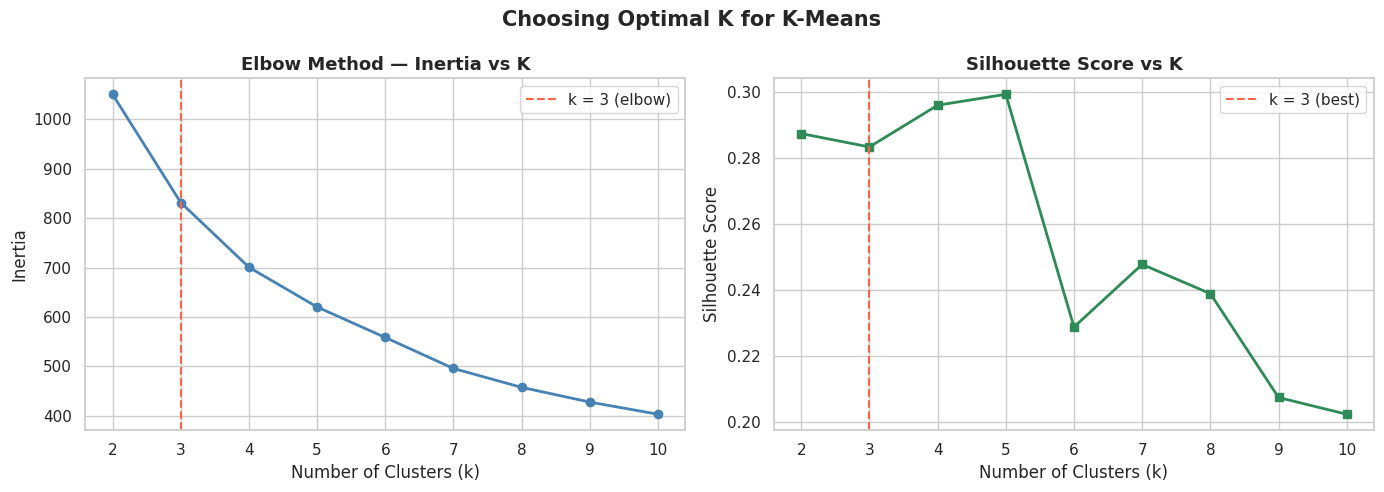


Silhouette scores per k:
  k= 2  0.2874  ████████████████████████████
  k= 3  0.2833  ████████████████████████████
  k= 4  0.2960  █████████████████████████████
  k= 5  0.2993  █████████████████████████████
  k= 6  0.2287  ██████████████████████
  k= 7  0.2477  ████████████████████████
  k= 8  0.2388  ███████████████████████
  k= 9  0.2073  ████████████████████
  k=10  0.2022  ████████████████████


In [26]:
k_range    = range(2, 11)
inertias   = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# ── Plot both metrics side-by-side 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(k_range), inertias, marker='o', color='steelblue', linewidth=2)
ax1.axvline(x=3, color='tomato', linestyle='--', label='k = 3 (elbow)')
ax1.set_title('Elbow Method — Inertia vs K', fontsize=13, fontweight='bold')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.legend()

ax2.plot(list(k_range), silhouettes, marker='s', color='seagreen', linewidth=2)
ax2.axvline(x=3, color='tomato', linestyle='--', label='k = 3 (best)')
ax2.set_title('Silhouette Score vs K', fontsize=13, fontweight='bold')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.legend()

plt.suptitle('Choosing Optimal K for K-Means', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nSilhouette scores per k:")
for k, s in zip(k_range, silhouettes):
    bar = '█' * int(s * 100)
    print(f"  k={k:2d}  {s:.4f}  {bar}")

## 8. Train K-Means with k = 3

Both the elbow plot and silhouette analysis confirm **k = 3** as the optimal number of clusters.

In [27]:
BEST_K = 3

kmeans           = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, df['kmeans_cluster'])
print(f"✅ K-Means trained  |  k = {BEST_K}  |  Silhouette Score = {sil:.4f}")
print(f"\nCluster sizes:")
print(df['kmeans_cluster'].value_counts().sort_index().rename('count').to_string())

✅ K-Means trained  |  k = 3  |  Silhouette Score = 0.2833

Cluster sizes:
kmeans_cluster
0    36
1    47
2    84


## 9. DBSCAN — Density-Based Clustering

DBSCAN does not require a pre-specified number of clusters. It groups densely packed points and marks sparse points as **noise (-1)**.

We tune `eps` (neighbourhood radius) and `min_samples` using a parameter grid.

In [28]:
print(f"{'eps':>6} {'min_samples':>12} {'clusters':>10} {'noise pts':>10}")
print("-" * 45)

best_params = None

for eps in [1.0, 1.2, 1.5, 2.0, 2.5]:
    for ms in [3, 5]:
        db     = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_scaled)
        n_cl   = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        print(f"{eps:>6.1f} {ms:>12d} {n_cl:>10d} {n_noise:>10d}")

print("\n→ eps=1.5, min_samples=3 gives a reasonable 2-cluster result with manageable noise.")

   eps  min_samples   clusters  noise pts
---------------------------------------------
   1.0            3          6         72
   1.0            5          3         94
   1.2            3          4         41
   1.2            5          3         53
   1.5            3          2         25
   1.5            5          1         30
   2.0            3          1         11
   2.0            5          1         15
   2.5            3          1          6
   2.5            5          1          6

→ eps=1.5, min_samples=3 gives a reasonable 2-cluster result with manageable noise.


In [29]:
# ── Train best DBSCAN 
dbscan = DBSCAN(eps=1.5, min_samples=3)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print("DBSCAN cluster distribution:")
print(df['dbscan_cluster'].value_counts().sort_index().rename('count'))
print("\n(-1 = noise / outliers)")

DBSCAN cluster distribution:
dbscan_cluster
-1     25
 0    139
 1      3
Name: count, dtype: int64

(-1 = noise / outliers)


## 10. PCA Visualisation

Reduce 9 features to 2 principal components for plotting. This lets us visually inspect cluster quality.

In [30]:
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained by PC1 + PC2 : {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%  |  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")

Variance explained by PC1 + PC2 : 63.1%
  PC1: 46.0%  |  PC2: 17.2%


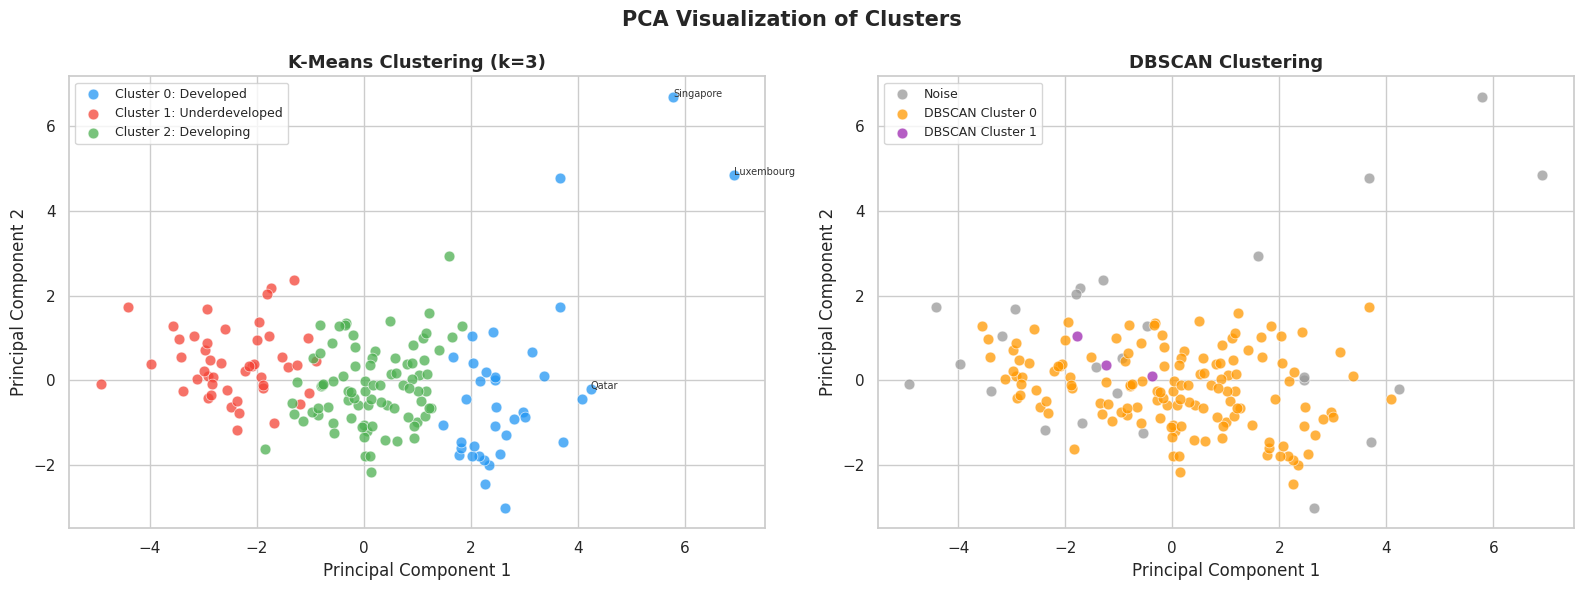

In [31]:
# ── Side-by-side: K-Means vs DBSCAN 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
cluster_labels = {0: 'Developed', 1: 'Underdeveloped', 2: 'Developing'}

# K-Means
scatter_data = pd.DataFrame({'PC1': X_pca[:,0], 'PC2': X_pca[:,1],
                              'cluster': df['kmeans_cluster'],
                              'country': df['country']})
colors = {0: '#2196F3', 1: '#F44336', 2: '#4CAF50'}
for cl, grp in scatter_data.groupby('cluster'):
    ax1.scatter(grp['PC1'], grp['PC2'], label=f"Cluster {cl}: {cluster_labels[cl]}",
                color=colors[cl], alpha=0.75, s=60, edgecolors='white', linewidths=0.5)

# Annotate a few extreme outliers
for _, row in scatter_data.nlargest(3, 'PC1').iterrows():
    ax1.annotate(row['country'], (row['PC1'], row['PC2']),
                 fontsize=7, color='#333')

ax1.set_title('K-Means Clustering (k=3)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')
ax1.legend(fontsize=9)

# DBSCAN
db_colors = {-1:'#999', 0:'#FF9800', 1:'#9C27B0', 2:'#00BCD4'}
for cl in sorted(df['dbscan_cluster'].unique()):
    mask = df['dbscan_cluster'] == cl
    label = 'Noise' if cl == -1 else f'DBSCAN Cluster {cl}'
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=label, color=db_colors.get(cl, '#333'),
                alpha=0.75, s=60, edgecolors='white', linewidths=0.5)

ax2.set_title('DBSCAN Clustering', fontsize=13, fontweight='bold')
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 2')
ax2.legend(fontsize=9)

plt.suptitle('PCA Visualization of Clusters', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Cluster Profiling

Compute the mean of every feature per cluster to understand what defines each group.

In [32]:
profile = df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)
profile.index = [f"Cluster {i} — {cluster_labels[i]}" for i in profile.index]
display(profile.T)

,Cluster 0 — Developed,Cluster 1 — Underdeveloped,Cluster 2 — Developing
child_mort,5.00,92.96,21.93
exports,58.74,29.15,40.24
health,8.81,6.39,6.20
imports,51.49,42.32,47.47
income,45672.22,3942.40,12305.60
inflation,2.67,12.02,7.60
life_expec,80.13,59.19,72.81
total_fer,1.75,5.01,2.31
gdpp,42494.44,1922.38,6486.45


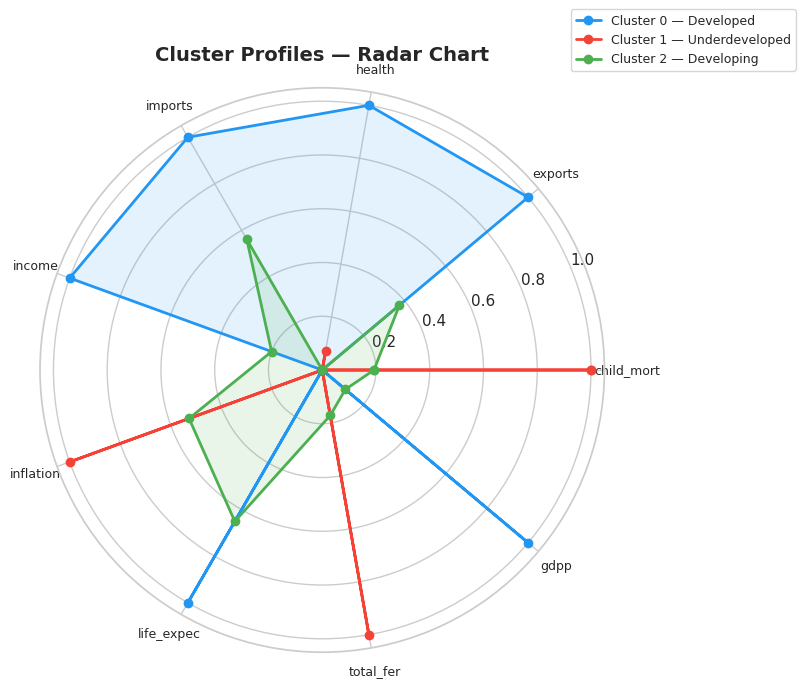

In [33]:
# Radar / Spider chart of cluster profiles 
from matplotlib.patches import FancyArrowPatch

# Normalise to [0,1] for radar chart
prof_norm = (profile - profile.min()) / (profile.max() - profile.min())
categories = list(prof_norm.columns)
N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

fig, ax = plt.subplots(figsize=(9, 7), subplot_kw=dict(polar=True))
palette = ['#2196F3', '#F44336', '#4CAF50']

for i, (idx, row) in enumerate(prof_norm.iterrows()):
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=idx, color=palette[i])
    ax.fill(angles, values, alpha=0.12, color=palette[i])

ax.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=9)
ax.set_title('Cluster Profiles — Radar Chart', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.show()

## 12. Countries by Cluster

In [34]:
for cl in sorted(df['kmeans_cluster'].unique()):
    label = cluster_labels[cl]
    countries = df[df['kmeans_cluster'] == cl]['country'].sort_values().tolist()
    print(f"\n{'─'*60}")
    print(f" Cluster {cl} — {label}  ({len(countries)} countries)")
    print('─'*60)
    # Print in 3 columns
    for i in range(0, len(countries), 3):
        row = countries[i:i+3]
        print("  " + "   ".join(f"{c:<25}" for c in row))


────────────────────────────────────────────────────────────
 Cluster 0 — Developed  (36 countries)
────────────────────────────────────────────────────────────
  Australia                   Austria                     Bahrain                  
  Belgium                     Brunei                      Canada                   
  Cyprus                      Czech Republic              Denmark                  
  Finland                     France                      Germany                  
  Greece                      Iceland                     Ireland                  
  Israel                      Italy                       Japan                    
  Kuwait                      Luxembourg                  Malta                    
  Netherlands                 New Zealand                 Norway                   
  Portugal                    Qatar                       Singapore                
  Slovak Republic             Slovenia                    South Korea             

## 13. Priority Countries for Aid

Countries in the **Underdeveloped** cluster (Cluster 1) are ranked by child mortality rate — the most critical indicator of human development need.

In [35]:
underdeveloped = (
    df[df['kmeans_cluster'] == 1]
    .sort_values('child_mort', ascending=False)
    [['country', 'child_mort', 'gdpp', 'life_expec', 'income', 'health']]
    .reset_index(drop=True)
)
underdeveloped.index += 1   # 1-based rank
underdeveloped.columns = ['Country', 'Child Mortality', 'GDP/capita', 'Life Expectancy', 'Income', 'Health Spend %']

print(" Top 15 Countries Needing Immediate Aid:\n")
display(underdeveloped.head(15).style
        .background_gradient(subset=['Child Mortality'], cmap='Reds')
        .background_gradient(subset=['GDP/capita'], cmap='Greens')
        .format({'Child Mortality': '{:.1f}', 'GDP/capita': '{:,.0f}',
                 'Life Expectancy': '{:.1f}', 'Income': '{:,.0f}', 'Health Spend %': '{:.2f}'}))

🚨 Top 15 Countries Needing Immediate Aid:



,Country,Child Mortality,GDP/capita,Life Expectancy,Income,Health Spend %
1,Haiti,208.0,662,32.1,"1,500",6.91
2,Sierra Leone,160.0,399,55.0,"1,220",13.10
3,Chad,150.0,897,56.5,"1,930",4.53
4,Central African Republic,149.0,446,47.5,888,3.98
5,Mali,137.0,708,59.5,"1,870",4.98
6,Nigeria,130.0,"2,330",60.5,"5,150",5.07
7,Niger,123.0,348,58.8,814,5.16
8,Angola,119.0,"3,530",60.1,"5,900",2.85
9,Burkina Faso,116.0,575,57.9,"1,430",6.74
10,"Congo, Dem. Rep.",116.0,334,57.5,609,7.91


## 14. Final Insights & Business Recommendations



### Recommendation to HELP International CEO
> **Allocate ≥70% of the $10 million fund to Cluster 1 nations**, prioritising Haiti, Sierra Leone, Chad, Central African Republic, and Mali based on highest child mortality and lowest healthcare spending. Reserve ~20% for high-impact Cluster 2 countries showing development momentum, and 10% for operational costs.
